$$
\textbf{Nome: Gabriel Souza Almeida. } \\
\textbf{Matrícula: 2026010096}
$$

$$
\textbf{Nome: Valderi Alves de Souza Neto. } \\
\textbf{Matrícula: 2026010167}
$$

In [1]:
import pandas as pd

df = pd.read_csv("Power_Plant_Data.csv")

#todas as correlações em função de PE
df_PEcorrel = df.corr()["PE"].drop("PE")

df_PEcorrel

AT   -0.948128
V    -0.869780
AP    0.518429
RH    0.389794
Name: PE, dtype: float64

# 1. Correlações com a variável alvo

Observa-se uma correlação forte (|r| > 0,7) das variáveis AT (temperatura ambiente) e V (vácuo) com a produção de energia (PE), indicando que são as variáveis com maior influência no modelo.

A variável AP (pressão atmosférica) apresenta correlação moderada a forte (|r| > 0,5), enquanto RH (umidade relativa) possui correlação moderada (|r| > 0,3). Isso sugere que ambas também influenciam a variável alvo, porém com menor intensidade em comparação a AT e V, sendo a influência de AP mais significativa que a de RH.

Abaixo, são apresentados os gráficos de dispersão das variáveis com maior correlação (AT e V) em relação à produção de energia. Neles, observa-se uma tendência aproximadamente linear, reforçando a relação entre essas variáveis explicativas e a variável alvo.

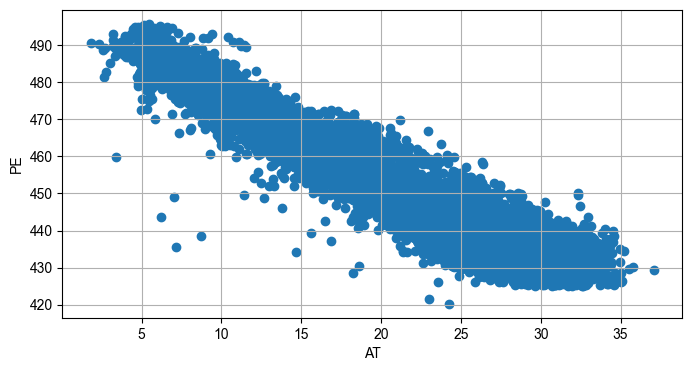

In [2]:
import matplotlib.pyplot as plt
X = df["AT"]
y = df["PE"]

#Muda a fonte dos Plots para Arial
plt.rcParams["font.family"] = "Arial"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams['mathtext.rm'] = "Arial"
plt.rcParams['mathtext.it'] = "Arial:italic"
plt.rcParams['mathtext.bf'] = "Arial:bold"
plt.rcParams['figure.figsize'] = (8, 4)

plt.scatter(X,y)
plt.xlabel('AT')
plt.ylabel('PE')
plt.grid()
plt.show()

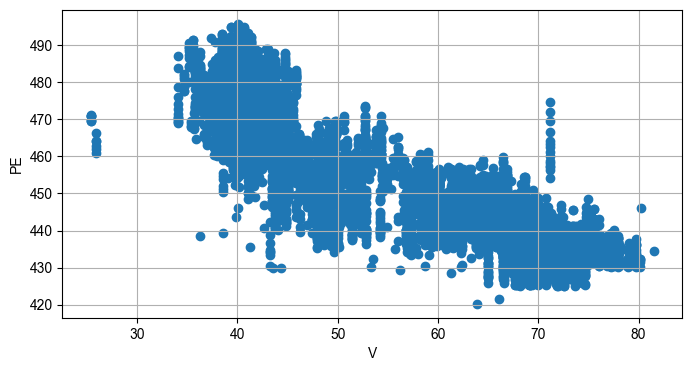

In [3]:
import matplotlib.pyplot as plt
X = df["V"]
y = df["PE"]

#Muda a fonte dos Plots para Arial
plt.rcParams["font.family"] = "Arial"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams['mathtext.rm'] = "Arial"
plt.rcParams['mathtext.it'] = "Arial:italic"
plt.rcParams['mathtext.bf'] = "Arial:bold"
plt.rcParams['figure.figsize'] = (8, 4)

plt.scatter(X,y)
plt.xlabel('V')
plt.ylabel('PE')
plt.grid()
plt.show()

In [4]:
correlacoes_ind = df[['AT', 'V', 'AP', 'RH']].corr()
print(correlacoes_ind)

          AT         V        AP        RH
AT  1.000000  0.844107 -0.507549 -0.542535
V   0.844107  1.000000 -0.413502 -0.312187
AP -0.507549 -0.413502  1.000000  0.099574
RH -0.542535 -0.312187  0.099574  1.000000


# 2. Correlações das variaveis entre si

A relação mais forte observada é entre AT (temperatura) e V (vácuo), com correlação de 0.84 (Nivel muito forte). Isso indica multicolinearidade, já que ambas carregam informações muito semelhantes para o modelo.

As relações entre AT e V com AP (pressão) e RH (umidade) são interessantes, onde as de AT apresentam correlação forte (0.507 e 0.54) e as de V apresentam correlação moderada (0.41 e 0.31), indicando alguma influência, mas sem uma multicolinearidade tão clara.

Por fim, a correlação entre AP e RH é muito baixa (0.10), mostrando que são variáveis praticamente independentes e representam aspectos distintos do ambiente.

In [5]:

#* Codigo feito com a normalização.

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

#Tudo menos nosso alvo
X = df.drop(columns=["PE"])

#Nosso alvo
y = df["PE"]

#Normalização
scaler  = MinMaxScaler(feature_range=(0, 1))
scaled  = scaler.fit_transform(X)
df_scaled = pd.DataFrame(scaled, columns=X.columns)
X = df_scaled

#Dividindo treinamento
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42
)

print(f"Tamanho do dataset = {X.shape[0]} amostras")
print(f"Quantidade de amostras de treinamento = {X_train.shape[0]} amostras")
print(f"Quantidade de amostras de teste = {X_test.shape[0]} amostras")

model = LinearRegression()
model.fit(X_train, y_train)

theta = model.coef_
theta_0 = model.intercept_

print(theta, theta_0)

Tamanho do dataset = 9568 amostras
Quantidade de amostras de treinamento = 7654 amostras
Quantidade de amostras de teste = 1914 amostras
[-70.10225923 -13.04365905   2.51349834 -11.7955869 ] 502.8049203381069


In [9]:
#Codigo feito sem a normalização.


from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

#Tudo menos nosso alvo
X = df.drop(columns=["PE"])

#Nosso alvo
y = df["PE"]



#Dividindo treinamento
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42
)

print(f"Tamanho do dataset = {X.shape[0]} amostras")
print(f"Quantidade de amostras de treinamento = {X_train.shape[0]} amostras")
print(f"Quantidade de amostras de teste = {X_test.shape[0]} amostras")

model = LinearRegression()
model.fit(X_train, y_train)

theta = model.coef_
theta_0 = model.intercept_

print(theta, theta_0)

Tamanho do dataset = 9568 amostras
Quantidade de amostras de treinamento = 7654 amostras
Quantidade de amostras de teste = 1914 amostras
[-1.98589969 -0.23209358  0.06219991 -0.15811779] 454.5691145894146


A normalização não afeta R², RMSE e MAE — o desempenho preditivo é o mesmo. O que muda são os coeficientes: com normalização eles ficam em escala comparável, permitindo identificar a importância relativa de cada variável. AT tem maior impacto (-70.10), seguido de V (-13.04) e RH (-11.79), o que é consistente com a correlação.

# 3. Interpretação dos coeficientes

A extração dos coeficientes permite visualizar a influência de cada variável na previsão da Produção de Energia (PE):

- **Intercepto** ($\theta_0 \approx 454{,}61$): representa o valor base teórico da produção de energia.

- **AT (-1,97) e V (-0,23)**: confirmam a forte relação inversa observada anteriormente. A temperatura ambiente (AT) é o fator de maior impacto negativo no modelo.

- **AP (0,06) e RH (-0,15)**: apresentam influência menor, atuando como ajustes finos relacionados à pressão e à umidade.

A titulo de organização, a equação com esses coeficientes ficaria: $$PE = 454,61 - 1,98 \cdot AT - 0,23 \cdot V + 0,06 \cdot AP - 0,16 \cdot RH$$

In [7]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import math

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = math.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"MAE: {mae:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"R²: {r2:.6f}")

MAE: 3.595913
RMSE: 4.502633
R²: 0.930105


# 4. Avaliação e justificativa do modelo

Com base nas métricas de desempenho obtidas, o modelo se mostra altamente adequado para prever a produção de energia ($PE$). A seguir, a justificativa técnica:

- **$R^2 \approx 0,93$**: indica que o modelo explica aproximadamente 93% da variabilidade da produção de energia. Para um fenômeno físico influenciado por múltiplas variáveis ambientais, esse é um resultado bastante elevado.

- **Magnitude dos erros ($MAE$ e $RMSE$)**: o erro médio absoluto ($MAE$) de 3,59 MW é baixo considerando que a produção da usina varia entre aproximadamente 420 e 500 MW. Isso representa um erro relativo inferior a 1%, conferindo alta confiabilidade às previsões.

- **Comparativo MAE vs RMSE**: a proximidade entre o MAE (3,59) e o RMSE (4,50) indica que os erros do modelo são consistentes. Como o RMSE é mais sensível a outliers, o fato de seu valor não se distanciar muito do MAE sugere ausência de grandes desvios, reforçando a estabilidade e a confiabilidade das previsões.

Para complementar a análise numérica, o gráfico abaixo reforça a qualidade do modelo: o gráfico de valores reais vs. predições mostra os pontos próximos da linha ideal, sem nenhum desvio acentuado em nenhuma região.

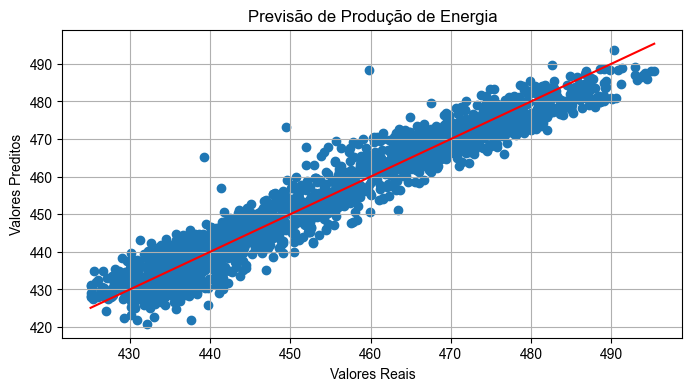

In [8]:
import matplotlib.pyplot as plt
import numpy as np

y_test_min = np.min(y_test)
y_test_max = np.max(y_test)

y_ideal = np.linspace(y_test_min, y_test_max, 1000)

plt.plot(y_ideal, y_ideal, 'r')
plt.scatter(y_test, y_pred)
plt.xlabel("Valores Reais")
plt.ylabel("Valores Preditos")
plt.title("Previsão de Produção de Energia")
plt.grid(True)
plt.show()